## Part 1

In [ ]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("uciml/indian-liver-patient-records")

# First let's explore the data
df = pd.read_csv(path + "/indian_liver_patient.csv")

# Take a look at some rows and overall numbers across dataset
print("First 5 rows:")
display(df.head())
print("Last 5 rows:")
display(df.tail())
print("Shape:", df.shape,"\n")
print("Info:")
df.info()
print("\nSummary Statistics:")
display(df.describe())

# Missing values or duplicates
print("Null values: \n", df.isnull().sum()) # 4 nulls in Albumin_and_Globulin_Ratio column
print("\nDuplicate rows:", df.duplicated().sum()) # 13 duplicates

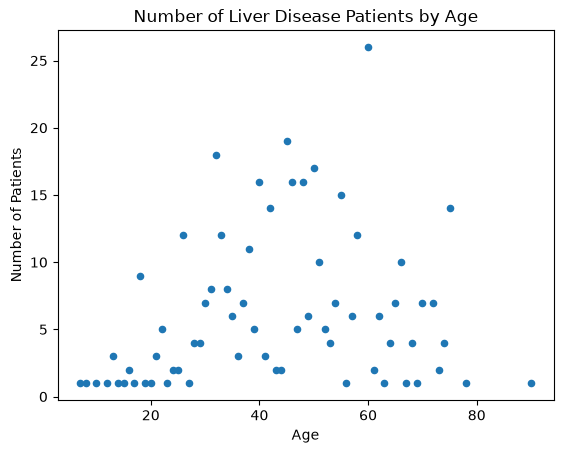

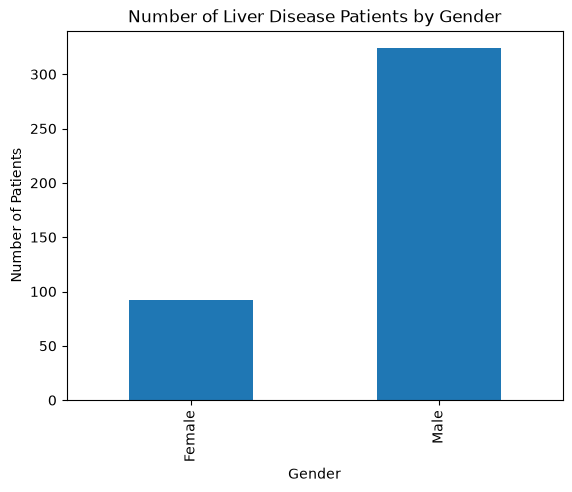

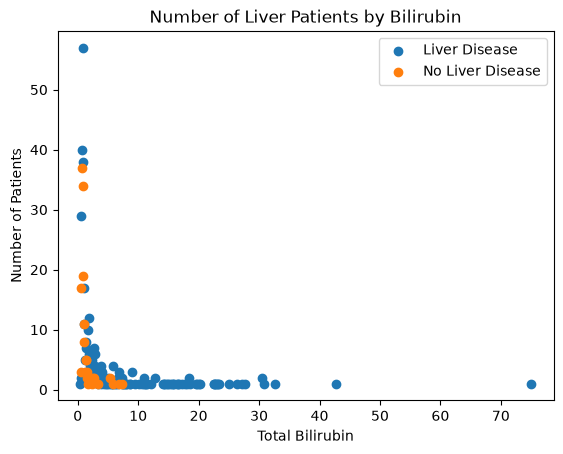

In [ ]:
import matplotlib.pyplot as plt

# Create some plots to see how some columns correlate with disease
# Data shows that younger patients are less likely to have liver disease
age_plot = df.iloc[df['Dataset']==1].groupby('Age')[['Dataset']].count().reset_index() # Queried ChatGPT to find out I needed to reset_index
age_plot.plot(x='Age',y='Dataset', kind='scatter', title='Number of Liver Disease Patients by Age', ylabel='Number of Patients')

# Data shows that males are more likely to have liver disease than females
gender_plot = df.iloc[df['Dataset']==1].groupby('Gender')[['Dataset']].count().reset_index()
gender_plot.plot(x='Gender', y='Dataset', kind='bar', title='Number of Liver Disease Patients by Gender', ylabel='Number of Patients', legend=False)

# Data shows that patients with higher bilirubin levels are more likely to have liver disease, this makes sense as the liver processes bilirubin
plt.figure()
bilirubin_plot1 = df.iloc[df['Dataset']==1].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
bilirubin_plot2 = df.iloc[df['Dataset']==2].groupby('Total_Bilirubin')[['Dataset']].count().reset_index()
plt.scatter(bilirubin_plot1['Total_Bilirubin'], bilirubin_plot1['Dataset'], label='Liver Disease')
plt.scatter(bilirubin_plot2['Total_Bilirubin'], bilirubin_plot2['Dataset'], label='No Liver Disease')
plt.xlabel('Total Bilirubin')
plt.ylabel('Number of Patients')
plt.title('Number of Liver Patients by Bilirubin')
plt.legend()
plt.show()

# 
